In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     

PULSE_FOLDER = "/home/vita/projects/NV_sensing/DATA/AVG_PULSE"
A_RESULTS_CSV_PATH = "/home/vita/projects/NV_sensing/A_MATRIX/A_results.csv"
B_RESULTS_CSV_PATH = "B_results.csv"

AXES_ORDER = ["d1", "d2", "d3", "d4"]
B_COMPONENTS = ["Bx", "By", "Bz"]

# Field of view used for plotting- greed
EXTENT_UM = [-100, 100, -100, 100]

OFF_TIME = (0.0000, 0.0500)
NEG_TIME = 0.0571  # single time point within original NEG interval
POS_TIME = 0.0627  # single time point within original POS interval

# Plot settings
CMAP_DIVERGING = "seismic"
CMAP_SIGNAL = "viridis"

In [6]:
# Expected array structure for pulse data
#   column 0       = time [s]
#   columns 1:end  = pixel voltage traces [V]

pulse_files = [
    os.path.join(PULSE_FOLDER, f"Pulse_avg_{axis}.npy")
    for axis in AXES_ORDER
]
pulse_arrays = [np.load(file) for file in pulse_files]

In [7]:
# Stack pulse data, sanity check 
time_s = pulse_arrays[0][:, 0]

for axis, arr in zip(AXES_ORDER, pulse_arrays):
    if not np.allclose(arr[:, 0], time_s):
        raise ValueError(f"Time axis mismatch in {axis}")

#   voltage_stack[channel, time, pixel]
voltage_stack = np.stack([arr[:, 1:] for arr in pulse_arrays], axis=0)

n_channels, n_timepoints, n_pixels = voltage_stack.shape
grid_size = int(np.sqrt(n_pixels))

if grid_size * grid_size != n_pixels:
    raise ValueError(f"Number of pixels is not square: {n_pixels}")

dt_s = np.median(np.diff(time_s))
frame_rate_hz = 1.0 / dt_s

print("voltage_stack shape:", voltage_stack.shape)
print("channels:", n_channels)
print("timepoints:", n_timepoints)
print("pixels:", n_pixels)
print("grid:", grid_size, "x", grid_size)
print(f"dt = {dt_s:.9f} s")
print(f"frame rate = {frame_rate_hz:.3f} Hz")

voltage_stack shape: (4, 457, 961)
channels: 4
timepoints: 457
pixels: 961
grid: 31 x 31
dt = 0.000386400 s
frame rate = 2587.992 Hz


In [8]:
#Build greed same as in experimental setup, to be used for plotting
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        # first column starts at bottom and goes up
        grid[row, grid_size - 1 - col] = idx
    else:
        # next column goes down
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx

,axis,pixel,OFF_mean_V,NEG_raw_V,POS_raw_V,NEG_minus_OFF_mV,POS_minus_OFF_mV
0,d1,480,6.584663e-06,-0.005650,0.002460,-5.656256,2.453541
1,d2,480,-8.100921e-07,-0.000790,0.000437,-0.788898,0.437895
2,d3,480,8.627914e-06,-0.000554,0.000519,-0.562161,0.510415
3,d4,480,-8.897403e-06,-0.000013,-0.000013,-0.003659,-0.004369


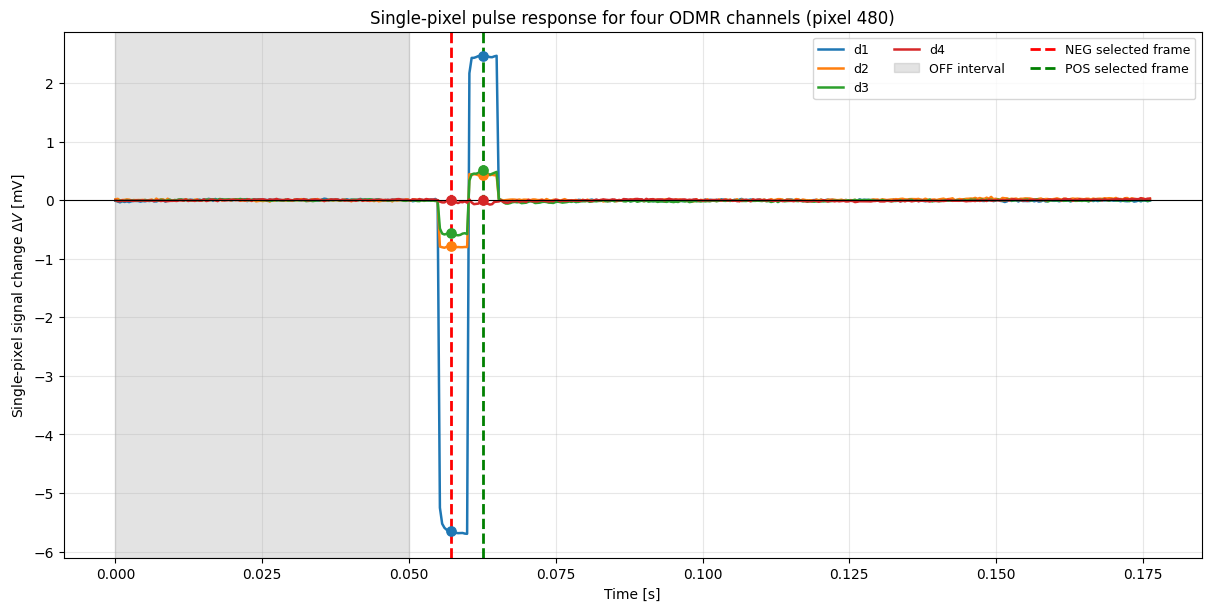

In [9]:
PULSE_AMPLITUDE_mV = 10.0
PULSE_AMPLITUDE_V = PULSE_AMPLITUDE_mV * 1e-3

CURRENT_AMPLITUDE_mA = 2.0

PIXEL_INDEX = 480

off_indices = np.where((time_s >= OFF_TIME[0]) & (time_s <= OFF_TIME[1]))[0]

neg_idx = np.argmin(np.abs(time_s - NEG_TIME))
pos_idx = np.argmin(np.abs(time_s - POS_TIME))

if len(off_indices) < 3:
    raise ValueError("OFF interval has too few frames. Adjust OFF_TIME.")


pixel_traces_V = voltage_stack[:, :, PIXEL_INDEX]  # [channel, time]

# OFF baseline per channel for this pixel
pixel_off_mean_V = np.nanmean(pixel_traces_V[:, off_indices], axis=1)
pixel_dV_mV = 1e3 * (pixel_traces_V - pixel_off_mean_V[:, None])

# Values at selected frames
selected_pixel_rows = []

for i, axis in enumerate(AXES_ORDER):
    selected_pixel_rows.append({
        "axis": axis,
        "pixel": PIXEL_INDEX,
        "OFF_mean_V": pixel_off_mean_V[i],
        "NEG_raw_V": pixel_traces_V[i, neg_idx],
        "POS_raw_V": pixel_traces_V[i, pos_idx],
        "NEG_minus_OFF_mV": pixel_dV_mV[i, neg_idx],
        "POS_minus_OFF_mV": pixel_dV_mV[i, pos_idx],
    })

selected_pixel_df = pd.DataFrame(selected_pixel_rows)
display(selected_pixel_df)

#add artificial poulse
pulse_mV = np.zeros_like(time_s, dtype=float)
current_mA = np.zeros_like(time_s, dtype=float)

pulse_mV[neg_idx] = -PULSE_AMPLITUDE_mV
pulse_mV[pos_idx] = +PULSE_AMPLITUDE_mV

current_mA[neg_idx] = -CURRENT_AMPLITUDE_mA
current_mA[pos_idx] = +CURRENT_AMPLITUDE_mA


frame_halfwidth = 1

pulse_display_mV = np.zeros_like(time_s, dtype=float)
current_display_mA = np.zeros_like(time_s, dtype=float)

neg_start = max(0, neg_idx - frame_halfwidth)
neg_end = min(len(time_s), neg_idx + frame_halfwidth + 1)

pos_start = max(0, pos_idx - frame_halfwidth)
pos_end = min(len(time_s), pos_idx + frame_halfwidth + 1)

pulse_display_mV[neg_start:neg_end] = -PULSE_AMPLITUDE_mV
pulse_display_mV[pos_start:pos_end] = +PULSE_AMPLITUDE_mV

current_display_mA[neg_start:neg_end] = -CURRENT_AMPLITUDE_mA
current_display_mA[pos_start:pos_end] = +CURRENT_AMPLITUDE_mA

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 6), constrained_layout=True)

# Four ODMR-channel traces
for i, axis in enumerate(AXES_ORDER):
    ax1.plot(
        time_s,
        pixel_dV_mV[i],
        lw=1.8,
        label=axis,
    )

# OFF / NEG / POS markers
ax1.axvspan(
    OFF_TIME[0],
    OFF_TIME[1],
    color="gray",
    alpha=0.22,
    label="OFF interval",
)

ax1.axvline(
    time_s[neg_idx],
    color="red",
    ls="--",
    lw=2,
    label="NEG selected frame",
)

ax1.axvline(
    time_s[pos_idx],
    color="green",
    ls="--",
    lw=2,
    label="POS selected frame",
)

# Mark selected points on each ODMR trace
for i, axis in enumerate(AXES_ORDER):
    ax1.scatter(
        [time_s[neg_idx], time_s[pos_idx]],
        [pixel_dV_mV[i, neg_idx], pixel_dV_mV[i, pos_idx]],
        s=45,
        zorder=5,
    )

ax1.axhline(0, color="black", lw=0.8)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel(r"Single-pixel signal change $\Delta V$ [mV]")
ax1.set_title(
    f"Single-pixel pulse response for four ODMR channels "
    f"(pixel {PIXEL_INDEX})"
)
ax1.grid(True, alpha=0.3)


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(
    lines1,
    labels1,
    ncol=3,
    fontsize=9,
    loc="best",
)

plt.show()

In [10]:

# Compute OFF / POS / NEG voltage arrays

V_off = np.nanmean(voltage_stack[:, off_indices, :], axis=1)   # [channel, pixel]
V_neg = voltage_stack[:, neg_idx, :]                           # [channel, pixel]
V_pos = voltage_stack[:, pos_idx, :]                           # [channel, pixel]

# Convert to mV and map back to 2D scan grid
Voff_maps_mV = 1e3 * V_off[:, grid]
Vpos_maps_mV = 1e3 * V_pos[:, grid]
Vneg_maps_mV = 1e3 * V_neg[:, grid]


## Convert V to frequency

In [13]:
# Load ODMR slopes and A_plus from A_results.csv

A_results_df = pd.read_csv(A_RESULTS_CSV_PATH)

available_groups = set(A_results_df["group"].unique())
required_groups = {"slope", "A_plus"}

missing_groups = required_groups - available_groups

if missing_groups:
    raise ValueError(
        f"A_results.csv is missing required groups: {missing_groups}. "
        "Rerun get_A_matrix.ipynb after saving slopes and A_plus."
    )



# Extract slopes and A_plus

slopes_V_per_MHz = np.zeros(4, dtype=float)

for i, axis in enumerate(AXES_ORDER):
    rows = A_results_df[
        (A_results_df["group"] == "slope") &
        (A_results_df["row"] == axis) &
        (A_results_df["col"] == "slope")
    ]

    if len(rows) == 0:
        raise ValueError(f"Missing slope for {axis}")

    unit = str(rows["unit"].iloc[0])
    if unit != "V/MHz":
        raise ValueError(f"Unexpected slope unit for {axis}: {unit}")

    slopes_V_per_MHz[i] = float(rows["value"].iloc[0])

Aplus_nT_per_MHz = np.zeros((3, 4), dtype=float)

for i, comp in enumerate(B_COMPONENTS):
    for j, axis in enumerate(AXES_ORDER):
        rows = A_results_df[
            (A_results_df["group"] == "A_plus") &
            (A_results_df["row"] == comp) &
            (A_results_df["col"] == axis)
        ]

        if len(rows) == 0:
            raise ValueError(f"Missing A_plus entry for {comp}, {axis}")

        value = float(rows["value"].iloc[0])
        unit = str(rows["unit"].iloc[0])

        if unit == "nT/MHz":
            Aplus_nT_per_MHz[i, j] = value
        elif unit == "mT/MHz":
            Aplus_nT_per_MHz[i, j] = 1e6 * value
        else:
            raise ValueError(f"Unexpected A_plus unit for {comp}, {axis}: {unit}")

slopes_df = pd.DataFrame({
    "axis": AXES_ORDER,
    "slope_V_per_MHz": slopes_V_per_MHz,
})

Aplus_df = pd.DataFrame(
    Aplus_nT_per_MHz,
    index=B_COMPONENTS,
    columns=AXES_ORDER,
)

print("ODMR slopes loaded from A_results.csv:")
display(slopes_df)

print("A_plus loaded from A_results.csv [nT/MHz]:")
display(Aplus_df)

ODMR slopes loaded from A_results.csv:


,axis,slope_V_per_MHz
0,d1,-0.005998
1,d2,-0.006857
2,d3,-0.002656
3,d4,-0.001930


A_plus loaded from A_results.csv [nT/MHz]:


,d1,d2,d3,d4
Bx,-22954.201722,-22530.378496,-407.550787,-322.273020
By,-1968.013835,-2925.969295,-22872.279877,-22384.337267
Bz,-15620.222190,15784.051464,-13867.328231,14754.846590


In [14]:
# Convert voltage changes to frequency shifts
#   Δν [MHz] = ΔV [V] / slope [V/MHz]
dV_pos = V_pos - V_off  
dV_neg = V_neg - V_off

deltaNu_pos_MHz = dV_pos / slopes_V_per_MHz[:, None]
deltaNu_neg_MHz = dV_neg / slopes_V_per_MHz[:, None]

deltaNu_rows = []

for i, axis in enumerate(AXES_ORDER):
    for phase, arr in [("pos-off", deltaNu_pos_MHz[i]), ("neg-off", deltaNu_neg_MHz[i])]:
        deltaNu_rows.append({
            "axis": axis,
            "phase": phase,
            "p50_abs_deltaNu_MHz": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_deltaNu_MHz": np.nanpercentile(np.abs(arr), 95),
            "max_abs_deltaNu_MHz": np.nanmax(np.abs(arr)),
        })

deltaNu_summary_df = pd.DataFrame(deltaNu_rows)
display(deltaNu_summary_df)

,axis,phase,p50_abs_deltaNu_MHz,p95_abs_deltaNu_MHz,max_abs_deltaNu_MHz
0,d1,pos-off,0.105711,0.503759,0.708268
1,d1,neg-off,0.126241,0.889923,1.082920
2,d2,pos-off,0.036378,0.092168,0.110807
3,d2,neg-off,0.062977,0.210918,0.262132
4,d3,pos-off,0.080814,0.180398,0.217456
5,d3,neg-off,0.083771,0.195773,0.250899
6,d4,pos-off,0.033865,0.097631,0.124235
7,d4,neg-off,0.026981,0.103887,0.145168


In [15]:
deltaNu_pos_maps = deltaNu_pos_MHz[:, grid]
deltaNu_neg_maps = deltaNu_neg_MHz[:, grid]


# 3. Apply A_plus and reconstruct magnetic field

In [17]:
# Formula:
#   B [nT] = A_plus [nT/MHz] @ Δν [MHz]

B_pos_nT = Aplus_nT_per_MHz @ deltaNu_pos_MHz
B_neg_nT = Aplus_nT_per_MHz @ deltaNu_neg_MHz

B_rows = []

for i, comp in enumerate(B_COMPONENTS):
    for phase, arr in [("pos-off", B_pos_nT[i]), ("neg-off", B_neg_nT[i])]:
        B_rows.append({
            "component": comp,
            "phase": phase,
            "p50_abs_B_nT": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_B_nT": np.nanpercentile(np.abs(arr), 95),
            "max_abs_B_nT": np.nanmax(np.abs(arr)),
        })

B_summary_df = pd.DataFrame(B_rows)

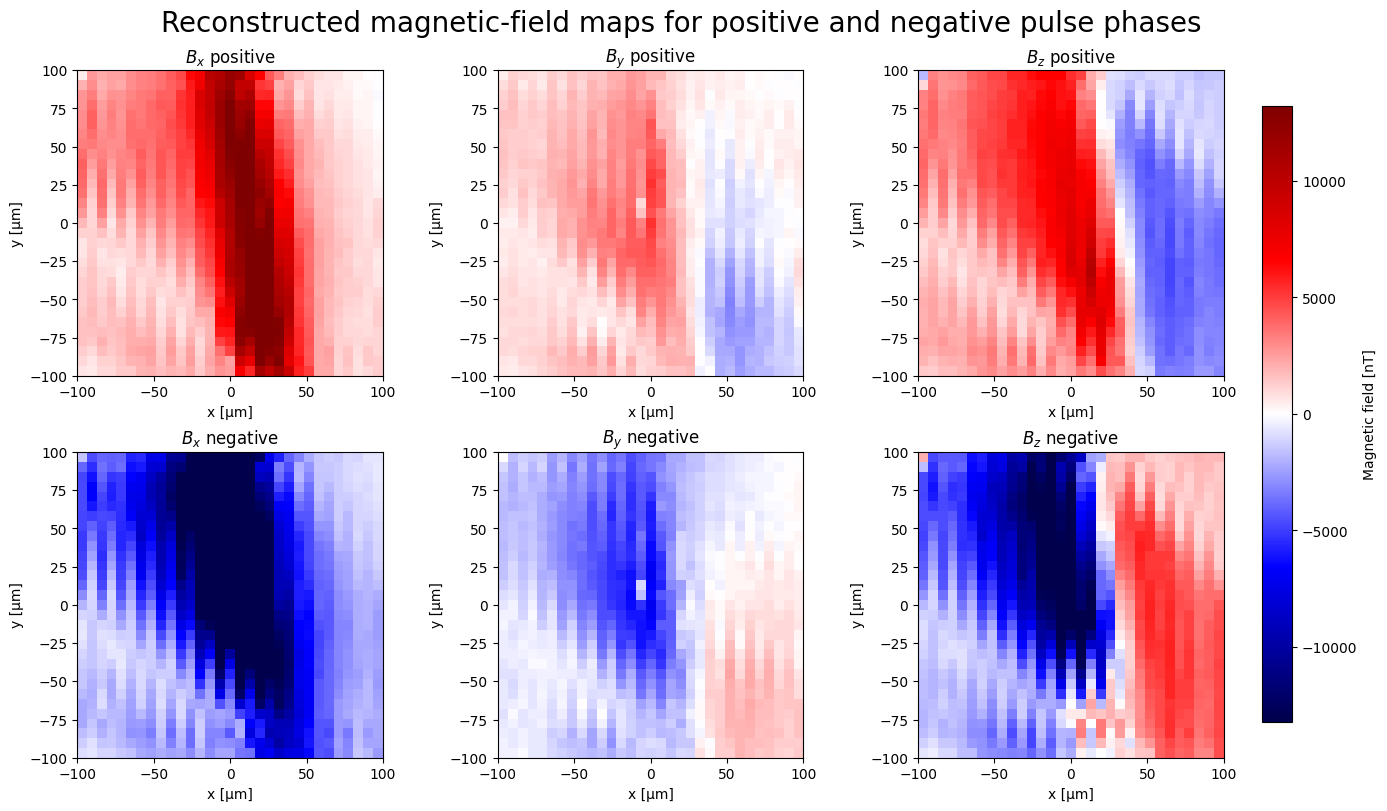

In [18]:
B_pos_maps = [B_pos_nT[i][grid] for i in range(3)]
B_neg_maps = [B_neg_nT[i][grid] for i in range(3)]

all_B_values = np.concatenate([
    B_pos_maps[0].ravel(), B_pos_maps[1].ravel(), B_pos_maps[2].ravel(),
    B_neg_maps[0].ravel(), B_neg_maps[1].ravel(), B_neg_maps[2].ravel(),
])

global_lim = np.nanpercentile(np.abs(all_B_values), 95)

if global_lim == 0 or not np.isfinite(global_lim):
    global_lim = 1.0

plot_items = [
    ("$B_x$ positive", B_pos_maps[0]),
    ("$B_y$ positive", B_pos_maps[1]),
    ("$B_z$ positive", B_pos_maps[2]),
    ("$B_x$ negative", B_neg_maps[0]),
    ("$B_y$ negative", B_neg_maps[1]),
    ("$B_z$ negative", B_neg_maps[2]),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for ax, (title, data) in zip(axes.ravel(), plot_items):
    im = ax.imshow(
        data,
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap=CMAP_DIVERGING,
        vmin=-global_lim,
        vmax=global_lim,
    )

    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")

# One shared colorbar for the full figure
cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.02,
)
cbar.set_label("Magnetic field [nT]")

fig.suptitle(
    "Reconstructed magnetic-field maps for positive and negative pulse phases",
    fontsize=20,
)

plt.show()

In [19]:
#SAVE
B_odd_nT = 0.5 * (B_pos_nT - B_neg_nT)
B_even_nT = 0.5 * (B_pos_nT + B_neg_nT)

x_values_um = np.linspace(EXTENT_UM[0], EXTENT_UM[1], grid_size)
y_values_um = np.linspace(EXTENT_UM[2], EXTENT_UM[3], grid_size)

rows = []

for row in range(grid_size):
    for col in range(grid_size):
        pixel = int(grid[row, col])

        out = {
            "pixel": pixel,
            "row": row,
            "col": col,
            "x_um": float(x_values_um[col]),
            "y_um": float(y_values_um[row]),

            "OFF_start_s": float(OFF_TIME[0]),
            "OFF_end_s": float(OFF_TIME[1]),
            "OFF_first_frame": int(off_indices[0]),
            "OFF_last_frame": int(off_indices[-1]),

            "POS_time_requested_s": float(POS_TIME),
            "NEG_time_requested_s": float(NEG_TIME),
            "POS_time_actual_s": float(time_s[pos_idx]),
            "NEG_time_actual_s": float(time_s[neg_idx]),
            "POS_frame": int(pos_idx),
            "NEG_frame": int(neg_idx),
        }

        for i, axis in enumerate(AXES_ORDER):
            out[f"dV_pos_{axis}_V"] = float(dV_pos[i, pixel])
            out[f"dV_neg_{axis}_V"] = float(dV_neg[i, pixel])
            out[f"deltaNu_pos_{axis}_MHz"] = float(deltaNu_pos_MHz[i, pixel])
            out[f"deltaNu_neg_{axis}_MHz"] = float(deltaNu_neg_MHz[i, pixel])

        for i, comp in enumerate(B_COMPONENTS):
            out[f"{comp}_pos_nT"] = float(B_pos_nT[i, pixel])
            out[f"{comp}_neg_nT"] = float(B_neg_nT[i, pixel])
            out[f"{comp}_odd_nT"] = float(B_odd_nT[i, pixel])
            out[f"{comp}_even_nT"] = float(B_even_nT[i, pixel])

        rows.append(out)

B_results_df = pd.DataFrame(rows)
B_results_df.to_csv(B_RESULTS_CSV_PATH, index=False)

metadata_df = pd.DataFrame([
    {"key": "coordinate_x", "value": "horizontal image axis; magnet line M1-to-M2"},
    {"key": "coordinate_y", "value": "vertical image axis; approximate wire direction"},
    {"key": "coordinate_z", "value": "optical axis; diamond surface normal"},
    {"key": "grid", "value": "31x31 serpentine grid; same grid used for plotting"},
    {"key": "phase_definition", "value": "OFF interval average; POS and NEG are single frames"},
    {"key": "OFF_TIME_s", "value": str(OFF_TIME)},
    {"key": "POS_TIME_requested_s", "value": POS_TIME},
    {"key": "NEG_TIME_requested_s", "value": NEG_TIME},
    {"key": "POS_TIME_actual_s", "value": float(time_s[pos_idx])},
    {"key": "NEG_TIME_actual_s", "value": float(time_s[neg_idx])},
    {"key": "POS_frame", "value": int(pos_idx)},
    {"key": "NEG_frame", "value": int(neg_idx)},

    {"key": "pulse_amplitude_V", "value": PULSE_AMPLITUDE_V},
    {"key": "pulse_amplitude_mV", "value": PULSE_AMPLITUDE_mV},
    {"key": "artificial_pulse_file", "value": "artificial_pulse_10mV.csv"},
    {"key": "pulse_timing_file", "value": "pulse_timing_10mV.csv"},
    {"key": "pulse_convention", "value": "0 V during OFF; -0.010 V during NEG; +0.010 V during POS"},

    {"key": "B_unit", "value": "nT"},
    {"key": "deltaNu_unit", "value": "MHz"},
    {"key": "dV_unit", "value": "V"},
    {"key": "note", "value": "B components assume corrected lab-frame A_results.csv"},

    {"key": "current_pos_A", "value": 2e-3},
    {"key": "current_neg_A", "value": -2e-3},
    {"key": "current_pos_mA", "value": 2.0},
    {"key": "current_neg_mA", "value": -2.0},
    {"key": "effective_wire_height_um_for_simulation", "value": 20.0},
])

metadata_df.to_csv("B_results_metadata.csv", index=False)

print(f"Saved {B_RESULTS_CSV_PATH}")
print("Saved B_results_metadata.csv")
print("B_results shape:", B_results_df.shape)
display(B_results_df.head())

Saved B_results.csv
Saved B_results_metadata.csv
B_results shape: (961, 43)


,pixel,row,col,x_um,y_um,OFF_start_s,OFF_end_s,OFF_first_frame,OFF_last_frame,POS_time_requested_s,...,Bx_odd_nT,Bx_even_nT,By_pos_nT,By_neg_nT,By_odd_nT,By_even_nT,Bz_pos_nT,Bz_neg_nT,Bz_odd_nT,Bz_even_nT
0,930,0,0,-100.000000,-100.0,0.0,0.05,0,129,0.0627,...,768.305717,-78.902889,545.428593,-322.467117,433.947855,111.480738,1438.798915,-707.985915,1073.392415,365.406500
1,929,0,1,-93.333333,-100.0,0.0,0.05,0,129,0.0627,...,603.254149,-81.547248,460.048292,-375.172839,417.610566,42.437726,1252.943629,-442.099771,847.521700,405.421929
2,868,0,2,-86.666667,-100.0,0.0,0.05,0,129,0.0627,...,1036.426016,-44.324033,637.042241,-200.989737,419.015989,218.026252,1743.018041,-959.321990,1351.170015,391.848026
3,867,0,3,-80.000000,-100.0,0.0,0.05,0,129,0.0627,...,1032.502767,-42.422899,742.977032,-544.401171,643.689101,99.287931,1711.726587,-952.796450,1332.261518,379.465069
4,806,0,4,-73.333333,-100.0,0.0,0.05,0,129,0.0627,...,1378.114306,-13.535066,1058.538880,-539.910169,799.224524,259.314356,1907.558928,-1659.127275,1783.343102,124.215826
